Goal: Predict sales prices and practice feature engineering, RFs, and gradient boosting

1. Creative feature engineering 
2. Advanced regression techniques like random forest and gradient boosting

Submission Format:
Id,SalePrice
1461,169000.1
1462,187724.1233
1463,175221
etc.

Notes:
1. Exclude outliers
2. Preprocess = dups, missing val, inconsistent 

Algorithm/Psuedocode
1. Normalization (Min Max Scale)
2. nd exclusion of outliers

(ALSO PRACTICE)


In [539]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
# from catboost import CatBoopython
import lightgbm as lgb

In [540]:
df = pd.read_csv("../data/train.csv")


In [541]:
num_of_columns = df.columns
print(f"Num of columns: {len(num_of_columns)}")
num_of_columns


Num of columns: 81


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [542]:
df = df.drop(['Id'], axis=1)
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


LotArea


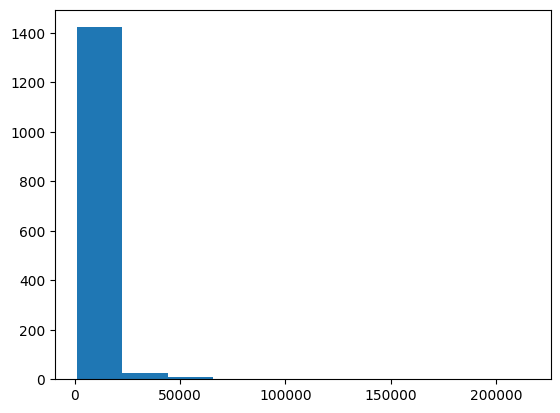

Sale Price


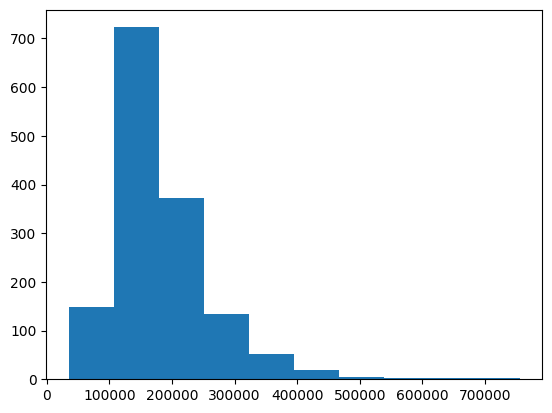

Overall quality


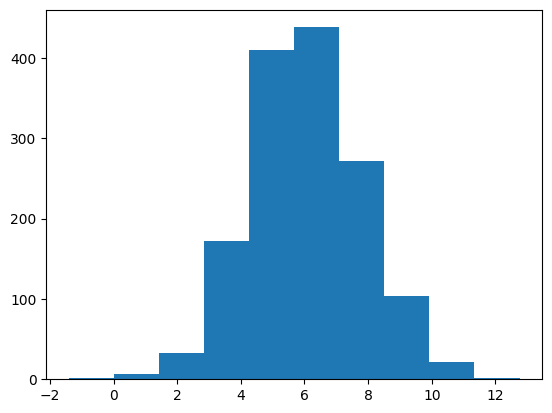

In [543]:
#Visualization for lotarea
lot_area = np.random.normal(df["LotArea"])
print("LotArea")
plt.hist(lot_area)
plt.show()

#Visualization for sale price
sale_price = np.random.normal(df["SalePrice"])
print("Sale Price")
plt.hist(sale_price)
plt.show()

#Overall quality (ordinal)
overal_quality = np.random.normal(df["OverallQual"])
print("Overall quality")
plt.hist(overal_quality)
plt.show()

LotFrontage


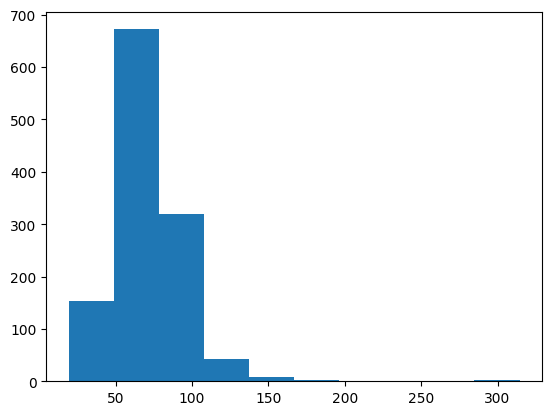

In [544]:
LotFrontage = np.random.normal(df["LotFrontage"])
print("LotFrontage")
plt.hist(LotFrontage)
plt.show()

MasVnrArea


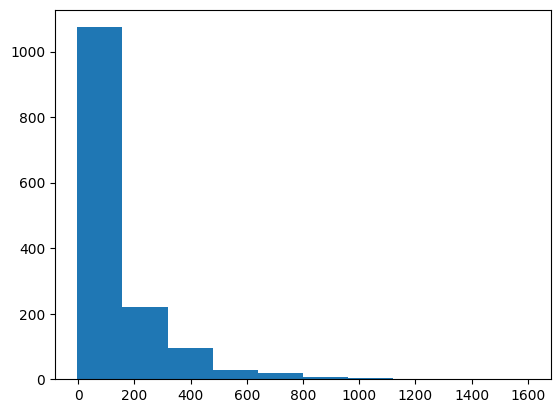

In [545]:
MasVnrArea = np.random.normal(df["MasVnrArea"])
print("MasVnrArea")
plt.hist(MasVnrArea)
plt.show()

In [546]:
missing_values = df.isnull().sum()
print(missing_values[missing_values>0])
    

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


<Axes: >

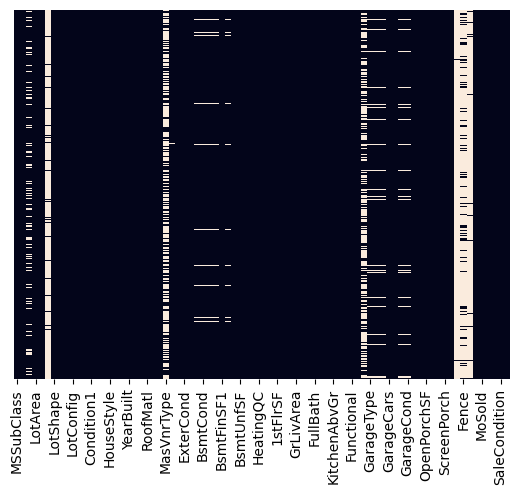

In [547]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [548]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [549]:
df.drop(["LotShape","Fence","PoolQC","MiscFeature","Alley"], axis=1, inplace=True)

In [550]:
#Fill missing values
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [551]:
df["BsmtCond"]=df["BsmtCond"].fillna(df["BsmtCond"].mode()[0])
df["BsmtQual"]=df["BsmtQual"].fillna(df["BsmtQual"].mode()[0])

In [552]:
df["FireplaceQu"] = df["FireplaceQu"].fillna(df["FireplaceQu"].mode()[0])
df["GarageType"] = df["GarageType"].fillna(df["GarageType"].mode()[0])

In [553]:
df["LotFrontage"]= df["LotFrontage"].fillna(df["LotFrontage"].mean())

In [554]:
#Got lazy so here's a loop to handle missing values on QL data
cat_col = df.select_dtypes(include="object").columns.tolist()

for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [555]:
df["MasVnrArea"]= df["MasVnrArea"].fillna(df["MasVnrArea"].median())
df["GarageYrBlt"]= df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

In [556]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [557]:
#Handle categorical

In [558]:
columns = df.select_dtypes(include="object").columns.to_list()
print("Categorical columns found:", len(columns))
print("First few columns:", columns[:5])
print("Is 'LotShape' in columns?", 'LotShape' in columns)

Categorical columns found: 38
First few columns: ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig']
Is 'LotShape' in columns? False


In [559]:
def onehot_categorical(columns):
    df_final = final_df.copy()
    
    for col in columns:
        if col in df_final.columns: 
            df1 = pd.get_dummies(df_final[col], drop_first=True, prefix=col)
            
            df_final = df_final.drop([col], axis=1)
            df_final = pd.concat([df_final, df1], axis=1)
    
    return df_final

In [560]:
main_df = df.copy()

In [561]:
test_df = pd.read_csv("newtest.csv")

In [562]:
print(test_df.shape)
print(df.shape)

(1459, 75)
(1460, 75)


In [563]:
# Check if test_df has LotShape before concatenating
print("Columns in test_df that are object dtype:")
test_object_cols = test_df.select_dtypes(include="object").columns
print(test_object_cols.tolist())

# Apply same column drops to test_df before concatenating
test_df = test_df.drop(["LotShape","Fence","PoolQC","MiscFeature","Alley"], axis=1, errors='ignore')

final_df = pd.concat([test_df,df],axis=0)

Columns in test_df that are object dtype:
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [564]:
final_df.shape

# Get categorical columns from the concatenated dataframe
columns = final_df.select_dtypes(include="object").columns.to_list()
print("Categorical columns in final_df:", len(columns))
print("First few columns:", columns[:5])

Categorical columns in final_df: 38
First few columns: ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig']


In [565]:
final_df = onehot_categorical(columns)

In [566]:
final_df.shape

(2919, 233)

In [567]:
final_df =final_df.loc[:,~final_df.columns.duplicated()]

In [568]:
final_df.shape

(2919, 233)

In [569]:
# Separate train and test data properly
# The original df had SalePrice, test_df doesn't
train_data = final_df[final_df['SalePrice'].notna()].copy()
test_data = final_df[final_df['SalePrice'].isna()].copy()

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Reset indices to avoid index alignment issues
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Split train data into train/validation
train_df, test_df_split = train_test_split(train_data, test_size=0.2, random_state=42)
test_df = test_data.copy()  # Use the actual test data without SalePrice

Train data shape: (1460, 233)
Test data shape: (1459, 233)


In [570]:
test_df.drop(["SalePrice"], axis=1, inplace=True)

In [571]:
X_train = train_df.drop(["SalePrice"], axis=1)
y_train = train_df["SalePrice"]

# Check for problematic values in target variable
print("NaN values in y_train:", y_train.isnull().sum())
print("Infinity values in y_train:", np.isinf(y_train).sum())
print("Very large values (>1e6):", (y_train > 1e6).sum())
print("Very small values (<0):", (y_train < 0).sum())
print("y_train shape:", y_train.shape)
print("X_train shape:", X_train.shape)

# Check the actual values
print("\ny_train describe:")
print(y_train.describe())

# Remove rows where SalePrice is NaN or problematic
valid_indices = y_train.notna() & ~np.isinf(y_train) & (y_train > 0) & (y_train < 1e6)
print(f"\nValid indices count: {valid_indices.sum()} out of {len(valid_indices)}")

X_train = X_train[valid_indices]
y_train = y_train[valid_indices]
print(f"After cleaning - X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

NaN values in y_train: 0
Infinity values in y_train: 0
Very large values (>1e6): 0
Very small values (<0): 0
y_train shape: (1168,)
X_train shape: (1168, 232)

y_train describe:
count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

Valid indices count: 1168 out of 1168
After cleaning - X_train shape: (1168, 232), y_train shape: (1168,)


In [572]:
# Check data types before fitting
print("Data types in X_train:")
print(X_train.dtypes.value_counts())

# Check if there are any object columns remaining
object_cols = X_train.select_dtypes(include='object').columns
if len(object_cols) > 0:
    print(f"\nFound {len(object_cols)} object columns that need to be converted:")
    print(object_cols.tolist())
else:
    print("\nNo object columns found - ready for XGBRegressor!")

classifier = XGBRegressor()
classifier.fit(X_train, y_train)

Data types in X_train:
bool       196
int64       25
float64     11
Name: count, dtype: int64

No object columns found - ready for XGBRegressor!


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [573]:
from sklearn.ensemble import RandomForestRegressor

# Use only first feature for simple 2D visualization
X_train_simple = X_train.iloc[:, 0].values.reshape(-1, 1)  # Only first feature, reshape to 2D
regressor = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)

In [574]:
def fit_regressor():
    regressor.fit(X_train_simple, y_train)

In [575]:
#Visualization 
def visualize(X_train_simple, column_name):
    X_grid = np.arange(min(X_train_simple[:, 0]), max(X_train_simple[:, 0]), 0.01)
    X_grid = X_grid.reshape(-1, 1)

    plt.figure(figsize=(10, 6))

    # Plot actual vs predicted
    y_pred = regressor.predict(X_train_simple)
    plt.scatter(X_train_simple[:, 0], y_train, color='blue', alpha=0.6, label="Actual Data")
    plt.scatter(X_train_simple[:, 0], y_pred, color='red', alpha=0.6, label="Predicted Values")

    # Create smooth prediction line
    y_grid = regressor.predict(X_grid)
    plt.plot(X_grid[:, 0], y_grid, color='green', linewidth=2, label="Regression Line")

    plt.title(f"Random Forest Regression - {column_name} vs Sale Price")
    plt.xlabel(column_name)
    plt.ylabel('Sale Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [576]:
#Making prediction and evaluation
from sklearn.metrics import r2_score

#estimates model's generalization performance
def predict_evaluate():    
    oob_score = regressor.oob_score_
    print(f"Out of bag score: {oob_score:.2f}")

    prediction = regressor.predict(X_train_simple)  # Use X_train_simple, not X_train

    mse = mean_squared_error(y_train, prediction)
    print(f"Mean Squared error: {mse:.2f}")

    rsme = np.sqrt(mse)
    print(f"Root square mean error: {rsme:.2f}")

    r2 = r2_score(y_train, prediction)
    print(f"R square: {r2:.2f}")

In [577]:
fit_regressor()

c:\Users\doria\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [578]:
predict_evaluate()

Out of bag score: 0.18
Mean Squared error: 4476495537.29
Root square mean error: 66906.62
R square: 0.25


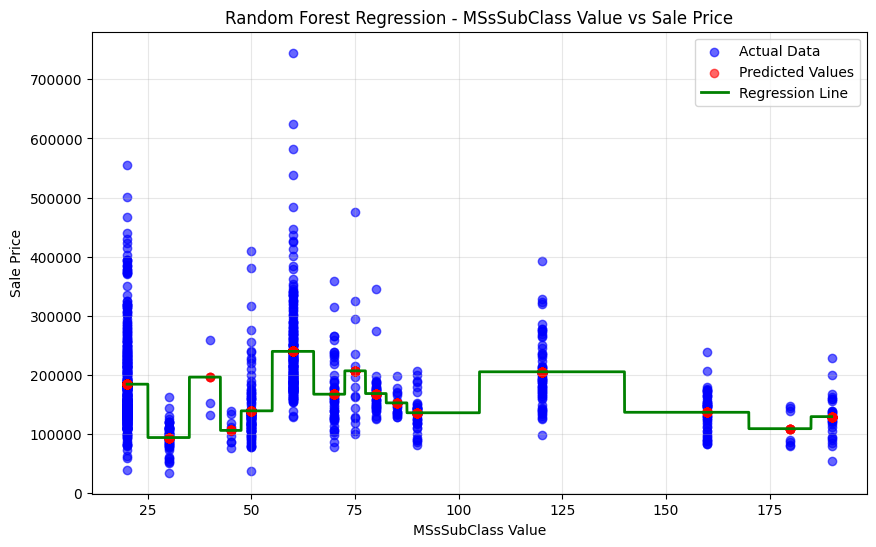

In [579]:
visualize(X_train_simple, column_name="MSsSubClass Value")

<div style=style="font-size: 12px">
   Now: Lot Area
</div>

In [580]:
print(X_train.iloc[:,2].name+"\n")
X_train_simple = X_train.iloc[:, 2].values.reshape(-1, 1)

LotArea



c:\Users\doria\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\doria\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


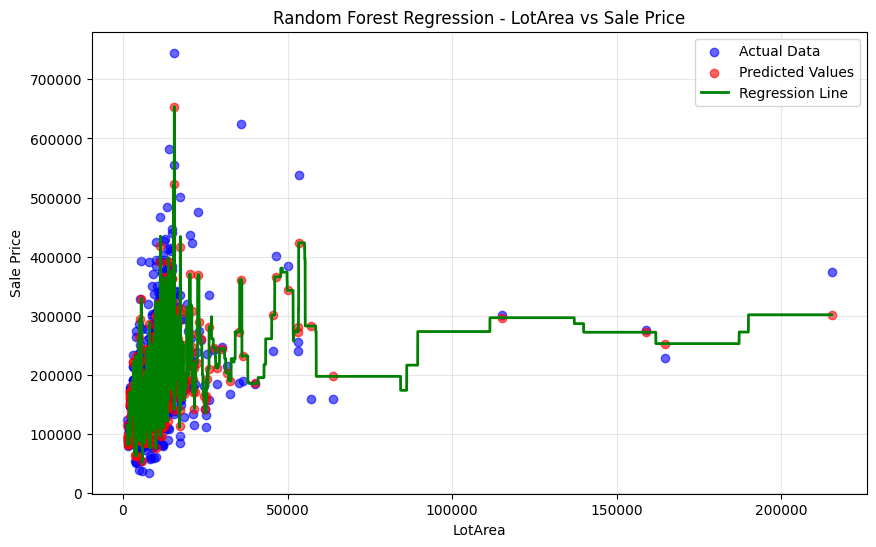

Out of bag score: -0.17
Mean Squared error: 1387831583.56
Root square mean error: 37253.61
R square: 0.77


In [581]:
fit_regressor()
visualize(X_train_simple, column_name="LotArea")
predict_evaluate()

In [582]:
final_df.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=233)

In [583]:
print(X_train.iloc[:,3].name+"\n")
X_train_simple = X_train.iloc[:, 3].values.reshape(-1, 1)

OverallQual



c:\Users\doria\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


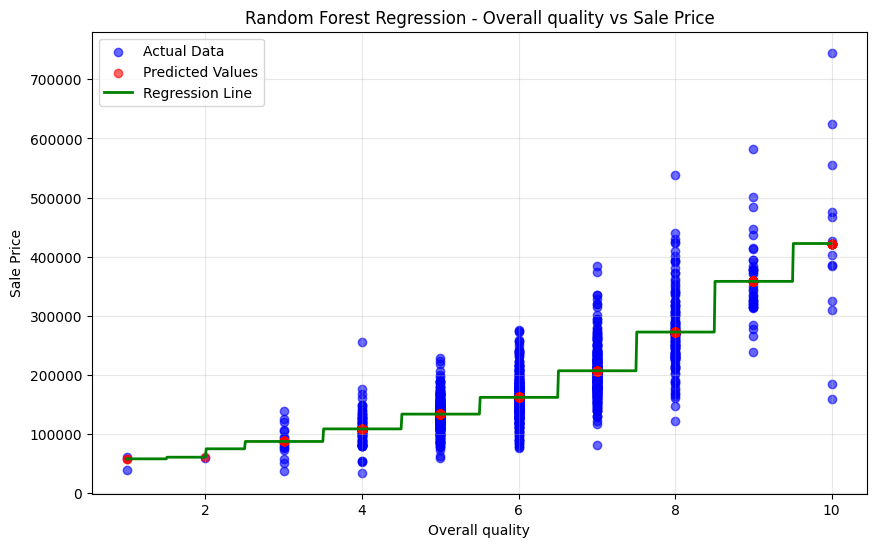

Out of bag score: 0.60
Mean Squared error: 1961873835.80
Root square mean error: 44293.05
R square: 0.67


In [584]:
fit_regressor()
visualize(X_train_simple, column_name="Overall quality")
predict_evaluate()

In [585]:
def change_value():
    # Recreate X_train and y_train after adding GarageAge column
    train_data = final_df[final_df['SalePrice'].notna()].copy()
    test_data = final_df[final_df['SalePrice'].isna()].copy()

    train_data = train_data.reset_index(drop=True)
    test_data = test_data.reset_index(drop=True)

    train_df, test_df_split = train_test_split(train_data, test_size=0.2, random_state=42)
    test_df = test_data.copy()

    X_train = train_df.drop(["SalePrice"], axis=1)
    y_train = train_df["SalePrice"]

    # Remove rows where SalePrice is NaN or problematic
    valid_indices = y_train.notna() & ~np.isinf(y_train) & (y_train > 0) & (y_train < 1e6)
    X_train = X_train[valid_indices]
    y_train = y_train[valid_indices]

    print(f"Updated X_train shape: {X_train.shape}")
    print(f"GarageAge column index: {X_train.columns.get_loc('GarageAge')}")

<h1>Garage Details</h1>
<p>Feature engineering</p>

In [586]:
final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,False,True,False,False,False,True,False
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,False,True,False,False,False,True,False
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [587]:
final_df["GarageAge"] = final_df["YrSold"] - final_df["GarageYrBlt"]

In [588]:
final_df.columns.get_loc("GarageAge")

233

In [589]:
change_value()

Updated X_train shape: (1168, 233)
GarageAge column index: 232


In [590]:
print(X_train.iloc[:,232].name+"\n")
X_train_simple = X_train.iloc[:, 232].values.reshape(-1, 1)

IndexError: single positional indexer is out-of-bounds

c:\Users\doria\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


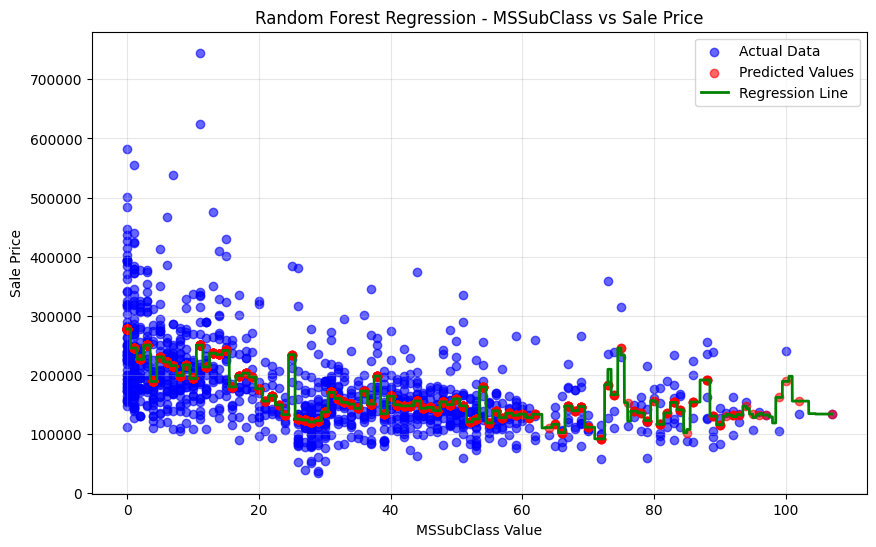

Out of bag score: 0.23
Mean Squared error: 3731218256.98
Root square mean error: 61083.70
R square: 0.37


In [ ]:
fit_regressor()
visualize(X_train_simple, column_name="GarageAge")
predict_evaluate()

In [ ]:
# Create Kaggle submission file using OverallQual model predictions
import pandas as pd

# Load the original test data to get IDs (since train_df doesn't have Id column)
original_test = pd.read_csv("../data/test.csv")

# Make predictions on test data using the OverallQual-based Random Forest model
# OverallQual is at index 3 in the processed data
overallqual_test_data = test_df.iloc[:, 3].values.reshape(-1, 1)
test_predictions = regressor.predict(overallqual_test_data)

# Create submission dataframe
submission = pd.DataFrame({
    'Id': original_test['Id'],
    'SalePrice': test_predictions
})

# Save to CSV
submission.to_csv('submission_overallqual.csv', index=False)

print("Submission file created successfully using OverallQual model!")
print(f"Submission shape: {submission.shape}")
print("\nFirst 5 rows:")
print(submission.head())

# Verify the format matches Kaggle requirements
print(f"\nColumns: {list(submission.columns)}")
print(f"Number of predictions: {len(submission)}")
print(f"Prediction range: ${test_predictions.min():.2f} - ${test_predictions.max():.2f}")

KeyError: 'Id'

In [ ]:
#Choosing overall quality
X_train_simple = X_train.iloc[:, 3].values.reshape(-1, 1)
y_pred = regressor.predict(X_train_simple)
submission = y_pred

new_df = pd.DataFrame({"Id":test_id.values,
"SalePrice": submission}
)

NameError: name 'test_id' is not defined